In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

UTA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

sample_folder = UTA_ROOT / "Fold1_part1" / "Fold1_part1" / "01"

print("Sample folder:", sample_folder)
print(os.listdir(sample_folder)[:10])

Sample folder: c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01
['0.mov', '10.MOV', '5.mov']


In [2]:
import cv2

video_path = sample_folder / "0.mov"

cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

print("FPS:", fps)
print("Total Frames:", frame_count)
print("Duration (seconds):", duration)

cap.release()

FPS: 29.968874071409797
Total Frames: 18053
Duration (seconds): 602.3916666666667


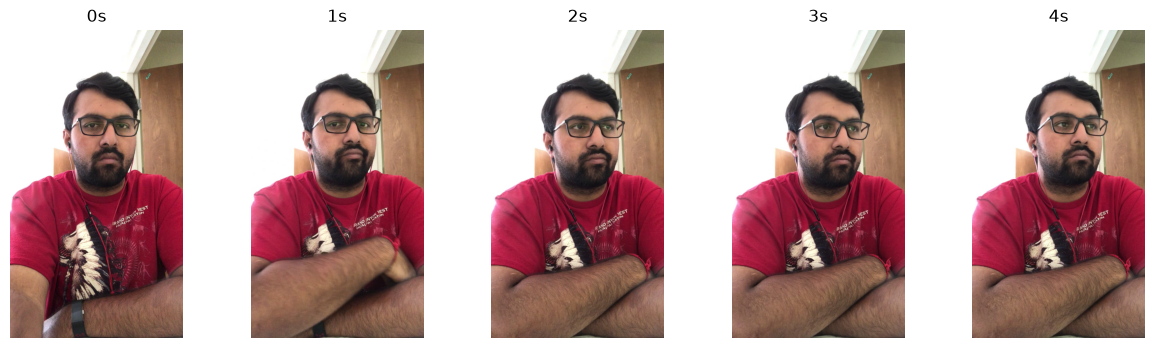

In [3]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(video_path))
fps = int(cap.get(cv2.CAP_PROP_FPS))

frames = []

for sec in range(min(5, int(cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps))):
    cap.set(cv2.CAP_PROP_POS_FRAMES, sec * fps)
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

cap.release()

plt.figure(figsize=(15, 4))

for i, frame in enumerate(frames):
    plt.subplot(1, len(frames), i + 1)
    plt.imshow(frame)
    plt.title(f"{i}s")
    plt.axis("off")

plt.show()

In [4]:
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection

face_detector = mp_face_detection.FaceDetection(
    model_selection=1,
    min_detection_confidence=0.5
)

In [5]:
frame = frames[0]

results = face_detector.process(frame)

print("Face detected:", results.detections is not None)

Face detected: True


c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [6]:
from pathlib import Path

OUTPUT_PATH = PROJECT_ROOT / "processed" / "UTA" / "sequences"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(OUTPUT_PATH)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\sequences


In [7]:
def preprocess_frame(frame):
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = face_detector.process(img_rgb)

    if not results.detections:
        return None

    detection = results.detections[0]
    bbox = detection.location_data.relative_bounding_box

    h, w, _ = img_rgb.shape

    x = int(bbox.xmin * w)
    y = int(bbox.ymin * h)
    bw = int(bbox.width * w)
    bh = int(bbox.height * h)

    padding = 20

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(w, x + bw + padding)
    y2 = min(h, y + bh + padding)

    face = img_rgb[y1:y2, x1:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, (224, 224))

    return cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

In [8]:
video_path = sample_folder / "0.mov"

video_name = video_path.stem
output_dir = OUTPUT_PATH / "01" / video_name
output_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(video_path))
fps = int(cap.get(cv2.CAP_PROP_FPS))

frame_idx = 0
saved = 0

while True:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx * fps)

    ret, frame = cap.read()
    if not ret:
        break

    processed = preprocess_frame(frame)

    if processed is not None:
        out_file = output_dir / f"frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(out_file), processed)
        saved += 1

    frame_idx += 1

cap.release()

print(f"Saved {saved} frames.")

Saved 622 frames.


Number of saved frames: 623


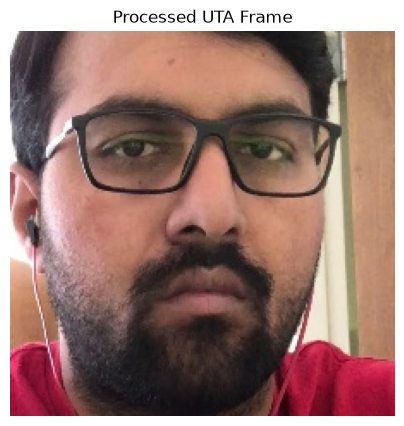

Shape: (224, 224, 3)


In [9]:
import matplotlib.pyplot as plt

saved_images = sorted(output_dir.glob("*.jpg"))

print("Number of saved frames:", len(saved_images))

img = cv2.imread(str(saved_images[0]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Processed UTA Frame")
plt.axis("off")
plt.show()

print("Shape:", img.shape)

In [26]:
for fold_dir in sorted(UTA_ROOT.iterdir()):
    if not fold_dir.is_dir():
        continue

    inner_dir = fold_dir / fold_dir.name  # e.g. Fold2_part1/Fold2_part1

    if not inner_dir.exists():
        continue

    for subject_dir in sorted(inner_dir.iterdir()):
        if subject_dir.is_dir():
            print(subject_dir.name, subject_dir)

01 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01
02 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\02
03 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\03
04 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\04
05 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\05
06 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\06
07 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\07
08 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\08
09 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\09
10 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\10
11 c:\Users\clark\OneDrive\Desktop\drowsiness_project\datase

In [33]:
from pathlib import Path
from tqdm import tqdm
import cv2

# Subjects already completed
completed_subjects = {"1", "2", "3","4", "5","6", "10", "16", "18", "19"}

for fold_dir in sorted(UTA_ROOT.iterdir()):

    if not fold_dir.is_dir():
        continue

    inner_dir = fold_dir / fold_dir.name
    if not inner_dir.exists():
        continue

    for subject_dir in sorted(inner_dir.iterdir()):

        if not subject_dir.is_dir():
            continue

        subject_num = str(int(subject_dir.name))

        if subject_num in completed_subjects:
            print(f"⏭️ Skipping subject {subject_num}")
            continue

        print(f"\n🚀 Processing subject {subject_num}")

        # NO DUPLICATES: collect files once, regardless of extension case
        video_files = sorted(
            [
                f for f in subject_dir.iterdir()
                if f.is_file() and f.suffix.lower() in [".mov", ".mp4"]
            ]
        )

        print(f"Found {len(video_files)} videos:")
        for v in video_files:
            print("  ", v.name)

        for video_path in tqdm(video_files, desc=f"Subject {subject_num}"):

            video_name = video_path.stem

            output_dir = OUTPUT_PATH / subject_num / video_name
            output_dir.mkdir(parents=True, exist_ok=True)

            cap = cv2.VideoCapture(str(video_path))

            fps = cap.get(cv2.CAP_PROP_FPS)
            if fps <= 0:
                fps = 30
            fps = max(1, int(round(fps)))

            frame_idx = 0
            saved_idx = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # ~1 frame per second
                if frame_idx % fps == 0:
                    processed = preprocess_frame(frame)

                    if processed is not None:
                        out_file = output_dir / f"frame_{saved_idx:04d}.jpg"
                        cv2.imwrite(str(out_file), processed)
                        saved_idx += 1

                frame_idx += 1

            cap.release()
            print(f"   ✅ {video_name}: {saved_idx} frames saved")

print("\n🎉 Remaining UTA preprocessing complete!")

⏭️ Skipping subject 1
⏭️ Skipping subject 2
⏭️ Skipping subject 3
⏭️ Skipping subject 4
⏭️ Skipping subject 5
⏭️ Skipping subject 6

🚀 Processing subject 7
Found 3 videos:
   0.mp4
   10.mp4
   5.mp4


Subject 7:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Subject 7:  33%|███▎      | 1/3 [03:57<07:54, 237.46s/it]

   ✅ 0: 601 frames saved


Subject 7:  67%|██████▋   | 2/3 [07:29<03:42, 222.58s/it]

   ✅ 10: 597 frames saved


...

   ✅ 0: 614 frames saved


Subject 48:  67%|██████▋   | 2/3 [04:13<02:11, 131.74s/it]

   ✅ 10: 613 frames saved


Subject 48: 100%|██████████| 3/3 [06:30<00:00, 130.20s/it]

   ✅ 5: 607 frames saved

🎉 Remaining UTA preprocessing complete!


In [35]:
total_frames = 0

for subject in (PROJECT_ROOT / "processed" / "UTA" / "sequences").iterdir():
    if subject.is_dir():
        for video in subject.iterdir():
            if video.is_dir():
                total_frames += len(list(video.glob("*.jpg")))

print("Total UTA frames:", total_frames)

from pathlib import Path

for dataset in ["NTHU", "MENDELEY"]:
    root = PROJECT_ROOT / "processed" / dataset

    print(f"\n{dataset}")
    for folder in root.rglob("*"):
        if folder.is_dir():
            count = len(list(folder.glob("*.jpg")))
            if count > 0:
                print(folder.relative_to(root), ":", count)

Total UTA frames: 88274

NTHU
alert : 29646
drowsy\sleepyCombination : 17390
drowsy\slowBlinkWithNodding : 9317
drowsy\yawning : 8568

MENDELEY
alert : 435
drowsy : 124
